<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h2>Ensemble - RandomForestClassifier</h2>
</div>

In [176]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [177]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display, print_evaluation
from scripts.decision_tree import determine_parameter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [178]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [179]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [180]:
X = df.drop(columns=['Default', 'LoanID'])#, 'DTIRatio', 'CreditScore'])
y = df['Default']

In [181]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 16) (51070, 16) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [182]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [183]:
numerical_features = X_train.select_dtypes(exclude='object').columns.tolist()
categorial_features = X_train.select_dtypes(include='object').columns.tolist()

In [184]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']), 
    ], remainder=MinMaxScaler()        
)

In [185]:
X_train = transformer.fit_transform(X_train)

In [186]:
X_test = transformer.transform(X_test)

In [187]:
from imblearn.over_sampling import SMOTE

In [188]:
smt = SMOTE()
xTrainSM, yTrainSM = smt.fit_resample(X_train, y_train)

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>3. RandomForestClassifier</h2>
</div>

In [189]:
from sklearn.ensemble import RandomForestClassifier

In [190]:
classifier = RandomForestClassifier(n_estimators=100, 
                            class_weight='balanced', 
                            random_state=42, 
                            n_jobs=-1, 
                            verbose=False, 
                            ccp_alpha=0.001,max_samples=0.8)

In [191]:
classifier.fit(X_train, y_train)

RandomForestClassifier(ccp_alpha=0.001, class_weight='balanced',
                       max_samples=0.8, n_jobs=-1, random_state=42,
                       verbose=False)

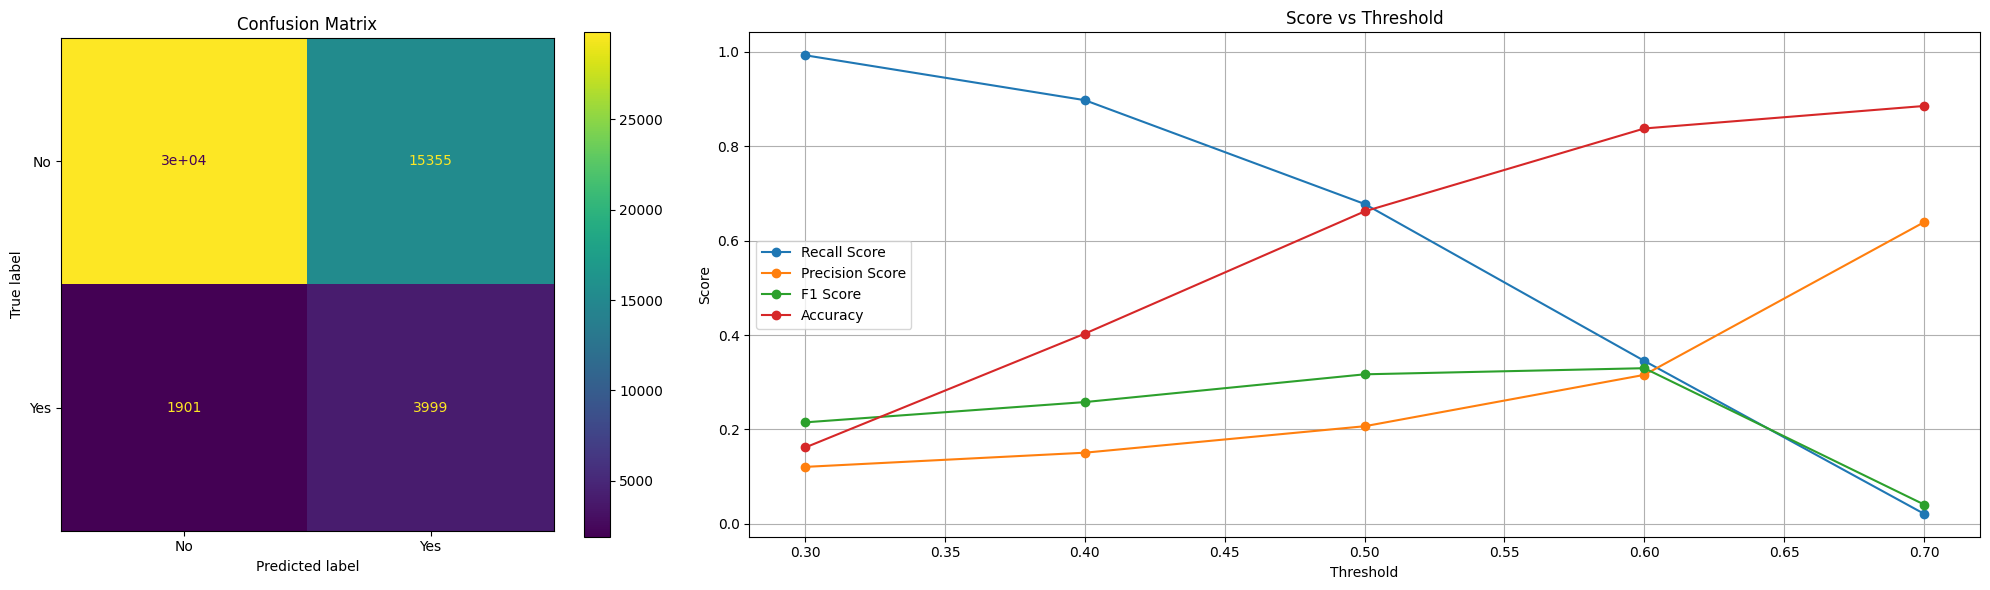

,Score,Percentage
0,Training Accuracy,66.20%
1,Test Accuracy,66.21%
2,Recall Score,2.10%
3,Precision Score,63.92%
4,Accuracy Score,88.55%
5,F1 Score,4.07%
6,ROC AUC Score,66.89%


In [192]:
scores_df, threshold_df = print_evaluation(classifier, X_train, y_train, X_test, y_test)
scores_df

In [193]:
threshold_df

,recall,precision,f1-score,accuracy
0.300,0.993,0.120,0.215,0.162
0.400,0.898,0.151,0.258,0.403
0.500,0.678,0.207,0.317,0.662
0.600,0.345,0.316,0.330,0.838
0.700,0.021,0.639,0.041,0.886
